# Eksperimen Q-Learning Scenario B

State: `(current_node, progress_bin)` — agen mengetahui node dan kategori progres jarak.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [10]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

Note: you may need to restart the kernel to use updated packages.


## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [13]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 2,500 episode


## 2. Jalankan training dan evaluasi

Cell ini menjalankan satu scenario saja. Hasilnya menampilkan tabel vertikal metrik evaluasi utama per seed, grafik training utama, grafik diagnosis ringkas (termasuk termination rate), dan peta rute interaktif.

Menjalankan Scenario B: 5 seed x 2,500 episode
seed=0: no_available_action, 4.73 km, is_loop=False
seed=1: over_distance, 5.61 km, is_loop=False
seed=2: no_available_action, 3.60 km, is_loop=False
seed=3: no_available_action, 4.01 km, is_loop=False
seed=4: no_available_action, 5.33 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,4733.425236,5611.382575,3601.388119,4010.348654,5326.350079
absolute_distance_error_m,266.574764,611.382575,1398.611881,989.651346,326.350079
total_reward,-72.472413,-104.194891,-84.976643,-70.778518,-80.878647
mean_comfort,0.779517,0.676402,0.740444,0.7092,0.723476
return_progress_ratio,0.689655,0.619048,0.421053,0.357143,0.525
distance_to_start_at_end_m,740.062477,709.06682,1183.696563,1393.748305,797.143577
termination_reason,no_available_action,over_distance,no_available_action,no_available_action,no_available_action


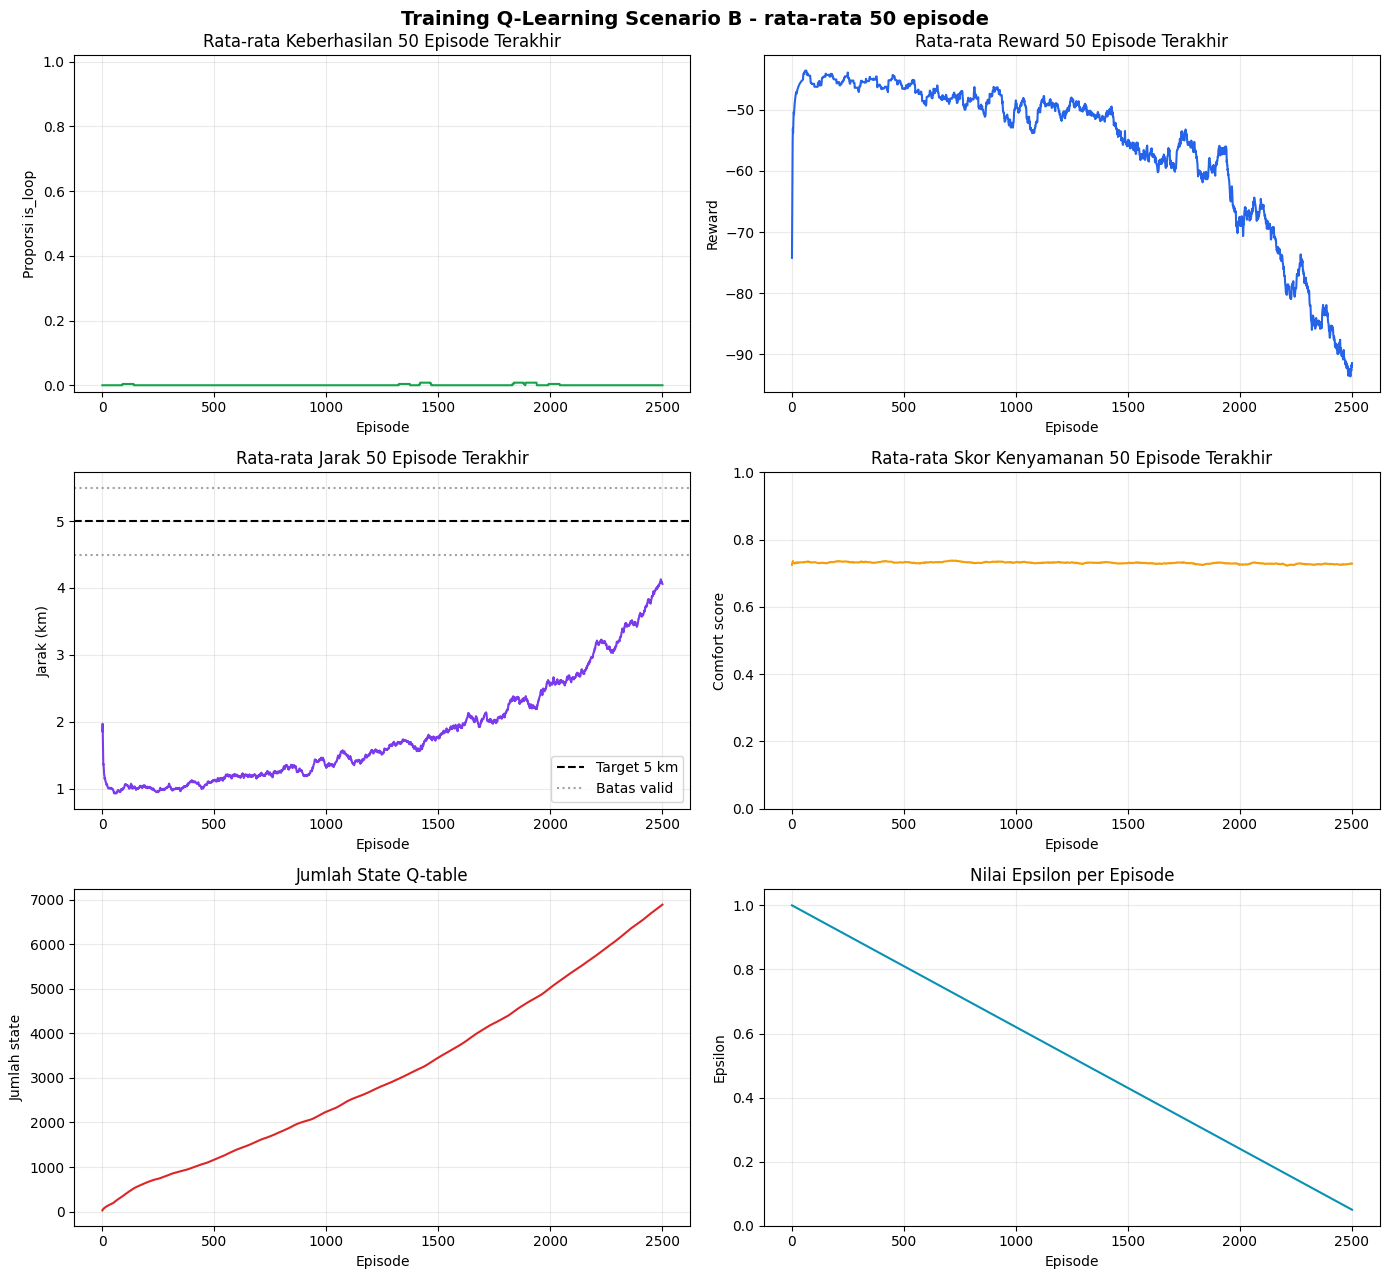

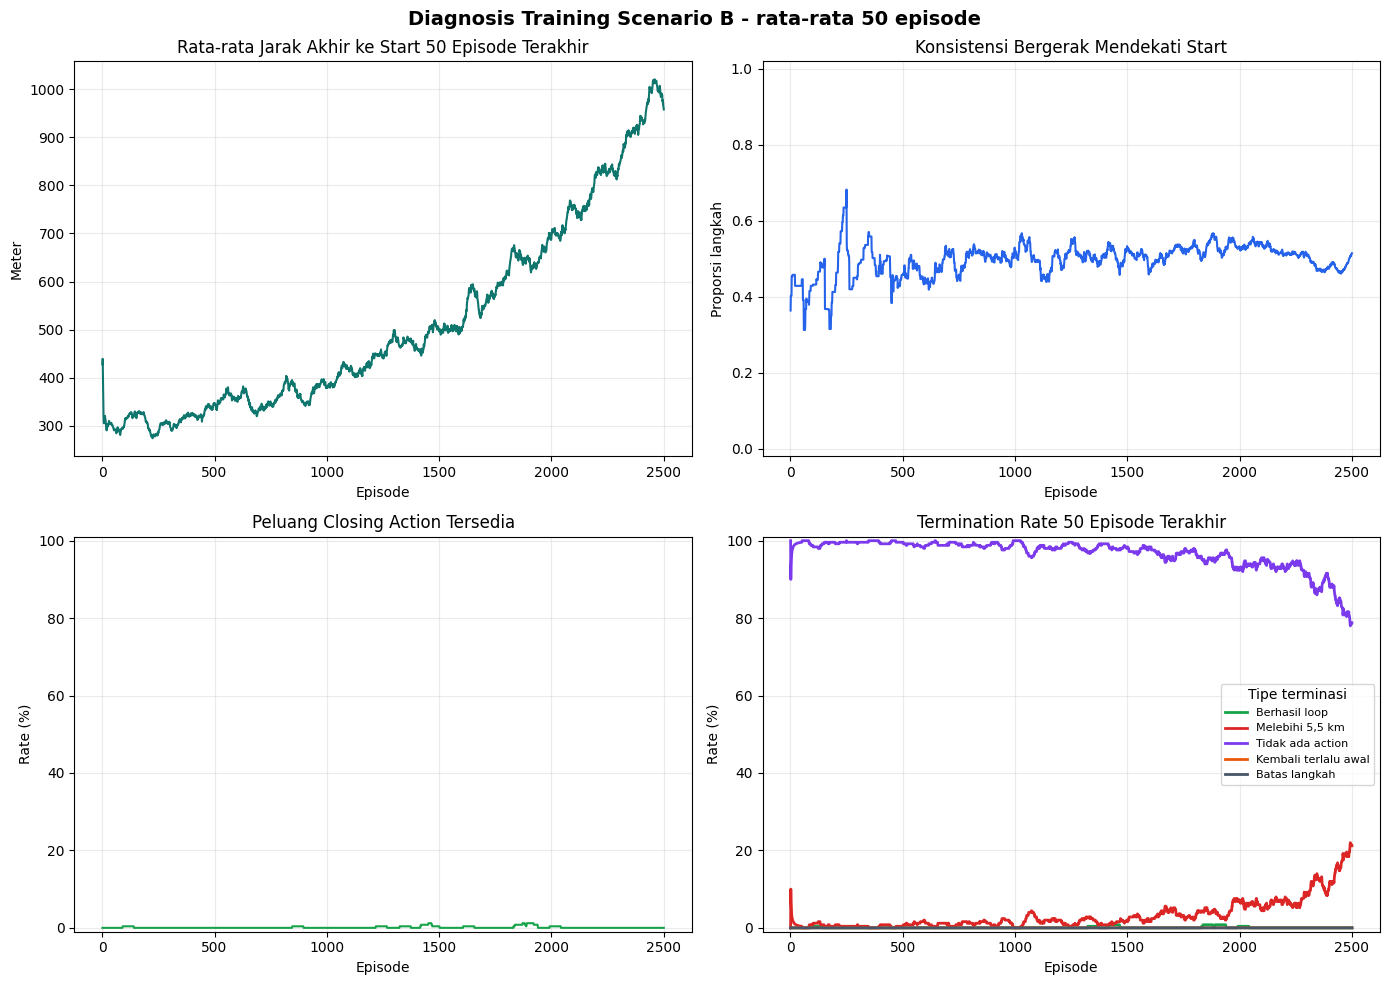

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 0
Metrik: is_loop=False, jarak=4733.43 m, galat=266.57 m, comfort=0.780, return_progress=0.690, jarak akhir ke start=740.06 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/grafik_training_B.png
Grafik diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [22]:
# Reload juga di cell ini agar aman bila cell training dijalankan ulang sendiri.
importlib.reload(rute_lari_core)
result_b = rute_lari_core.run_scenario_experiment(G, START_NODE, 'B')

## 3. Cara membaca hasil evaluasi

Tabel evaluasi utama memuat `is_loop`, `total_distance_m`, `absolute_distance_error_m`, `total_reward`, `mean_comfort`, `return_progress_ratio`, `distance_to_start_at_end_m`, dan `termination_reason`.

Grafik diagnosis tetap membantu menjelaskan proses training, khususnya termination rate dan ketersediaan closing action.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.